# Car Price Prediction Model using Machine Learning

**Project:** Car Price Prediction Model  
**Algorithm:** Random Forest Regressor  
**Interface:** Tkinter  
**Dataset:** Car Details v3 / Vehicle Dataset from CarDekho

This notebook follows the project report: data cleaning, feature engineering, encoding, scaling, Random Forest training, evaluation, model saving, and a Tkinter prediction interface.


## 1. Dataset Link

The dataset used in this notebook is the **Car Details v3.csv** dataset from the Kaggle Vehicle Dataset from CarDekho.

- Kaggle dataset: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
- Direct CSV mirror used by this notebook: https://raw.githubusercontent.com/HarshKapadia2/car-details/main/data/car_details_v3.csv

The dataset contains fields such as `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`, `mileage`, `engine`, `max_power`, `torque`, and `seats`. This matches the features described in your report. 


In [3]:
# Install packages if required
# !pip install pandas numpy scikit-learn matplotlib seaborn joblib

import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)


Matplotlib is building the font cache; this may take a moment.


## 2. Load the Dataset

The following cell downloads the CSV directly, so you do not need to manually upload it.

In [4]:
DATA_URL = "https://raw.githubusercontent.com/HarshKapadia2/car-details/main/data/car_details_v3.csv"

df = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())


Dataset loaded successfully.
Rows: 8128
Columns: 13


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
print("Column information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nStatistical summary:")
display(df.describe(include='all').T)


Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB

Missing values:


torque           222
seats            221
engine           221
mileage          221
max_power        215
fuel               0
km_driven          0
selling_price      0
year               0
name               0
owner              0
seller_type        0
transmission       0
dtype: int64


Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning and Feature Engineering

The report uses **vehicle age** as an important input. We calculate it from `year`. Text units such as `kmpl`, `CC`, and `bhp` are removed from numeric columns.

In [6]:
# Standardize column names
df.columns = [c.strip().lower() for c in df.columns]

# Remove completely empty rows
df = df.dropna(how='all').copy()

# Convert numeric columns
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')
df['km_driven'] = pd.to_numeric(df['km_driven'], errors='coerce')
df['seats'] = pd.to_numeric(df['seats'], errors='coerce')

# Extract numeric values from columns containing units
for col in ['mileage', 'engine', 'max_power']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.extract(r'([-+]?[0-9]*\.?[0-9]+)')[0],
            errors='coerce'
        )

# Vehicle age
CURRENT_YEAR = 2026
df['vehicle_age'] = CURRENT_YEAR - df['year']
df.loc[df['vehicle_age'] < 0, 'vehicle_age'] = np.nan

# Remove impossible target values
df = df[df['selling_price'].notna() & (df['selling_price'] > 0)].copy()

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (8128, 14)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,vehicle_age
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0,12.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0,12.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0,20.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0,16.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0,19.0


## 4. Select Features and Target

Features are selected according to the project report: vehicle age, kilometers driven, mileage, engine capacity, maximum power, seats, fuel type, seller type, and transmission type. The target is `selling_price`.

In [7]:
features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'fuel',
    'seller_type',
    'transmission'
]

target = 'selling_price'

# Keep only columns that exist
features = [c for c in features if c in df.columns]

X = df[features].copy()
y = df[target].copy()

numeric_features = [
    c for c in ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
    if c in features
]
categorical_features = [
    c for c in ['fuel', 'seller_type', 'transmission']
    if c in features
]

print("Features:", features)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target:", target)


Features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel', 'seller_type', 'transmission']
Numerical features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical features: ['fuel', 'seller_type', 'transmission']
Target: selling_price


## 5. Exploratory Data Analysis

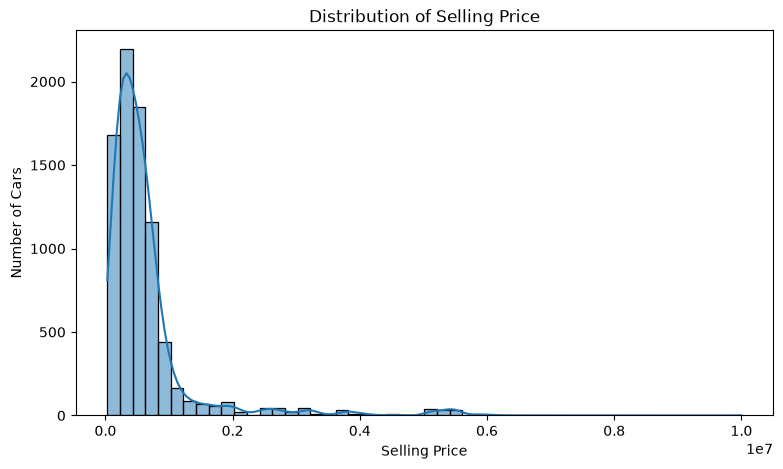

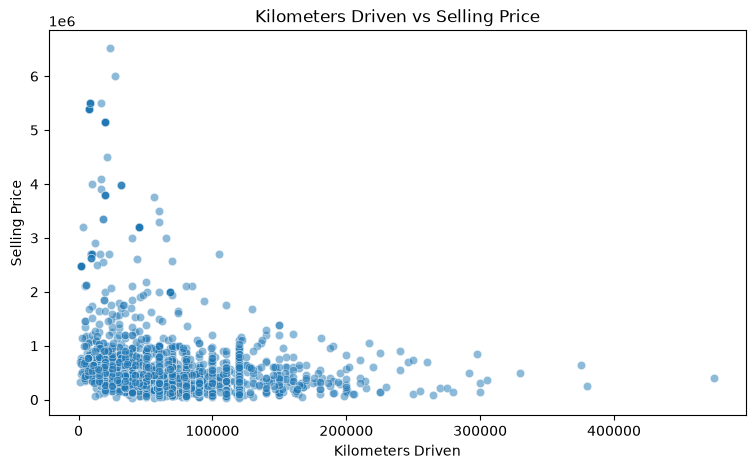

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.show()

plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42),
                x='km_driven', y='selling_price', alpha=0.5)
plt.title('Kilometers Driven vs Selling Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()


## 6. Train-Test Split and Preprocessing

Categorical variables are one-hot encoded and numerical variables are imputed and scaled. A `ColumnTransformer` keeps preprocessing consistent during both training and prediction.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Processed training shape:", X_train_processed.shape)


Training rows: 6502
Testing rows: 1626
Processed training shape: (6502, 15)


## 7. Train Random Forest Regressor

In [10]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_features='sqrt'
)

model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


## 8. Model Evaluation

In [11]:
y_pred = model.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")


MAE  : ₹70,162.43
RMSE : ₹144,456.51
R²   : 0.9682


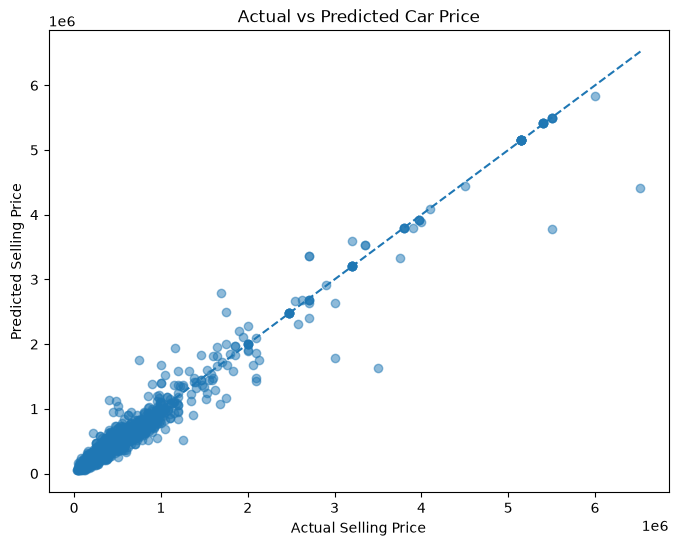

In [12]:
# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Price")

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle='--')
plt.show()


## 9. Feature Importance

,feature,importance
4,num__max_power,0.325397
3,num__engine,0.137055
0,num__vehicle_age,0.118921
13,cat__transmission_Automatic,0.092386
14,cat__transmission_Manual,0.091543
1,num__km_driven,0.075075
2,num__mileage,0.049820
10,cat__seller_type_Dealer,0.036747
11,cat__seller_type_Individual,0.022213
7,cat__fuel_Diesel,0.018851


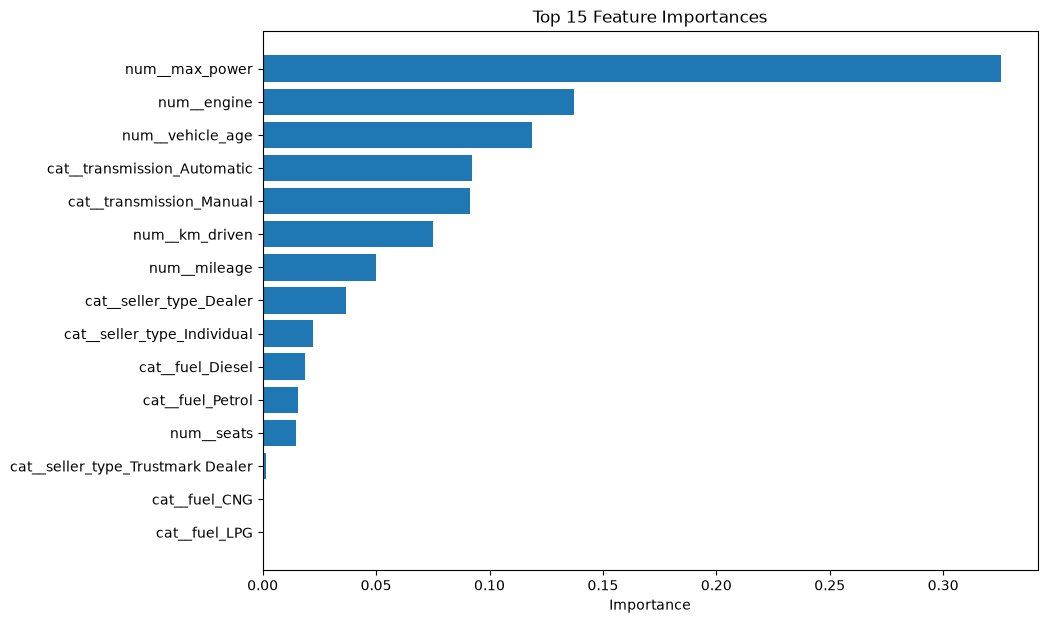

In [13]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance.head(15))

plt.figure(figsize=(10, 7))
top = importance.head(15).sort_values('importance')
plt.barh(top['feature'], top['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.show()


## 10. Save the Model and Preprocessor

In [14]:
joblib.dump(model, 'car_price_model.pkl')
joblib.dump(preprocessor, 'car_price_preprocessor.pkl')
joblib.dump(features, 'car_price_features.pkl')

print("Saved successfully:")
print("1. car_price_model.pkl")
print("2. car_price_preprocessor.pkl")
print("3. car_price_features.pkl")


Saved successfully:
1. car_price_model.pkl
2. car_price_preprocessor.pkl
3. car_price_features.pkl


## 11. Test a Single Prediction

In [15]:
sample = X_test.iloc[[0]]

sample_processed = preprocessor.transform(sample)
sample_prediction = model.predict(sample_processed)[0]

print("Sample input:")
display(sample)
print(f"Predicted Selling Price: ₹{sample_prediction:,.0f}")


Sample input:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel,seller_type,transmission
1971,22.0,110000,12.8,1493.0,100.0,5.0,Petrol,Individual,Manual


Predicted Selling Price: ₹157,145


# 12. Tkinter GUI

This GUI follows the report's application design: input fields for vehicle details, category selection, a **Predict Price** button, validation, and a displayed predicted price.

**Important:** Tkinter opens a separate desktop window. It works best when this notebook is run locally using Jupyter Notebook/JupyterLab. If you use Google Colab, save the GUI code as `app.py` and run it on your local computer.


In [16]:
# ============================================================
# 12. Tkinter GUI - Car Price Prediction
# ============================================================

import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd

# Create main window
root = tk.Tk()
root.title("Car Price Prediction")
root.geometry("650x700")
root.resizable(False, False)

# Main heading
title_label = tk.Label(
    root,
    text="Car Price Prediction",
    font=("Arial", 24, "bold")
)
title_label.pack(pady=20)

subtitle_label = tk.Label(
    root,
    text="Enter car details to predict its price",
    font=("Arial", 12)
)
subtitle_label.pack(pady=(0, 15))

# Form frame
form = tk.Frame(root)
form.pack(padx=30, pady=10)

# Numeric input fields
numeric_inputs = {
    "vehicle_age": "Vehicle Age (years)",
    "km_driven": "Kilometers Driven",
    "mileage": "Mileage (km/l)",
    "engine": "Engine (CC)",
    "max_power": "Max Power (bhp)",
    "seats": "Seats"
}

entries = {}

row = 0
for key, label_text in numeric_inputs.items():
    tk.Label(
        form,
        text=label_text + ":",
        font=("Arial", 12, "bold"),
        anchor="w",
        width=22
    ).grid(row=row, column=0, padx=10, pady=8, sticky="w")

    entry = tk.Entry(
        form,
        font=("Arial", 12),
        width=25
    )
    entry.grid(row=row, column=1, padx=10, pady=8)

    entries[key] = entry
    row += 1

# Categorical input fields
categorical_options = {
    "fuel": ["CNG", "Diesel", "LPG", "Petrol"],
    "seller_type": ["Dealer", "Individual", "Trustmark Dealer"],
    "transmission": ["Automatic", "Manual"]
}

combo_vars = {}

for key, options in categorical_options.items():
    label_text = key.replace("_", " ").title()

    tk.Label(
        form,
        text=label_text + ":",
        font=("Arial", 12, "bold"),
        anchor="w",
        width=22
    ).grid(row=row, column=0, padx=10, pady=8, sticky="w")

    var = tk.StringVar()
    combo = ttk.Combobox(
        form,
        textvariable=var,
        values=options,
        state="readonly",
        font=("Arial", 12),
        width=23
    )
    combo.grid(row=row, column=1, padx=10, pady=8)

    combo_vars[key] = var
    row += 1

# Result label
result_label = tk.Label(
    root,
    text="Predicted Car Price: ₹0",
    font=("Arial", 18, "bold")
)
result_label.pack(pady=15)


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------
def predict_price():
    try:
        # Get numeric values from input fields
        data = {}

        for key in numeric_inputs:
            value_text = entries[key].get().strip()

            if not value_text:
                raise ValueError(
                    f"Please enter {numeric_inputs[key]}."
                )

            value = float(value_text)

            if value < 0:
                raise ValueError(
                    f"{numeric_inputs[key]} cannot be negative."
                )

            data[key] = value

        # Validate seats
        if "seats" in data and not (1 <= data["seats"] <= 20):
            raise ValueError("Seats must be between 1 and 20.")

        # Get categorical values
        for key in categorical_options:
            value = combo_vars[key].get().strip()

            if not value:
                raise ValueError(
                    f"Please select {key.replace('_', ' ').title()}."
                )

            data[key] = value

        # IMPORTANT:
        # Use exactly the same feature order used while training.
        input_data = pd.DataFrame([data], columns=features)

        # Apply the same preprocessing used during model training
        input_processed = preprocessor.transform(input_data)

        # Predict
        predicted_price = model.predict(input_processed)[0]

        # Display prediction
        result_label.config(
            text=f"Predicted Car Price: ₹{predicted_price:,.0f}"
        )

    except ValueError as e:
        result_label.config(
            text="Invalid Input"
        )
        messagebox.showerror("Invalid Input", str(e))

    except Exception as e:
        result_label.config(
            text="Prediction Error"
        )
        messagebox.showerror(
            "Prediction Error",
            f"Could not generate prediction.\n\n{e}"
        )


# ------------------------------------------------------------
# Predict Price button
# ------------------------------------------------------------
predict_button = tk.Button(
    root,
    text="Predict Price",
    command=predict_price,
    font=("Arial", 14, "bold"),
    padx=25,
    pady=10
)

predict_button.pack(pady=20)

# Start GUI
root.mainloop()


## 13. Project Files

After running the notebook, these model files will be created:

- `car_price_model.pkl`
- `car_price_preprocessor.pkl`
- `car_price_features.pkl`

For the final project, keep the notebook, these `.pkl` files, and the dataset/application code together.

### Project workflow
**Dataset → Cleaning → Feature Engineering → Encoding & Scaling → Train/Test Split → Random Forest → Evaluation → Save Model → Tkinter GUI → Price Prediction**
